In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [2]:
df  = pd.read_csv("data/KNN_DataSet.csv")
df.head()

,user_id,gender,no_of_days,no_of_calls,enrolled,age
0,82238717,Male,24.502541,1.936580,1,69
1,75264736,Male,12.734882,1.448820,0,18
2,65851203,Female,15.594056,2.782494,0,39
3,50811194,Male,3.270349,4.791917,0,22
4,79334402,Male,15.335051,5.200419,0,45


In [3]:
df['enrolled'].value_counts()

enrolled
1    539
0    461
Name: count, dtype: int64

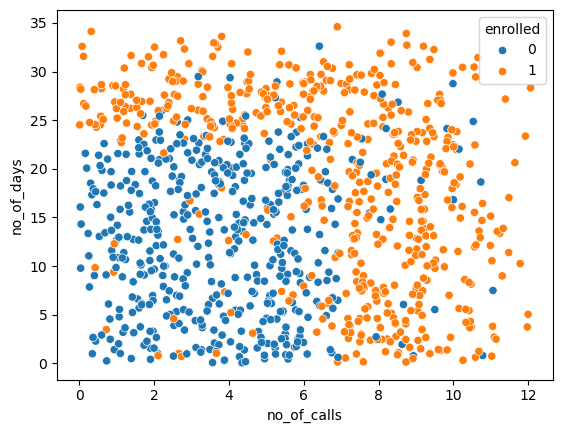

In [6]:
sns.scatterplot(data=df, x="no_of_calls", y="no_of_days", hue="enrolled");

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df[['no_of_calls', 'no_of_days']].values,
                                                    df['enrolled'].values,
                                                    test_size=0.33, random_state=42)

In [16]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

In [17]:
mu, sigma

(array([ 5.36497156, 15.78401161]), array([2.99581203, 9.18353967]))

In [18]:
X_train = (X_train - mu)/sigma
X_test = (X_test - mu)/sigma

### Imbalanced DataSet

In [26]:
X, y = make_classification(n_classes=2,
                           weights=[0.95, 0.05],
                           n_features=4,
                           n_samples=1000,
                           random_state=42)

df = pd.DataFrame(X, columns=['feature_1',
                              'feature_2',
                              'feature_3',
                              'feature_4'])


In [27]:
df['class'] = y

In [28]:
df.head()

,feature_1,feature_2,feature_3,feature_4,class
0,-1.194848,1.138331,-1.482079,1.025358,0
1,0.290131,0.317681,-0.996519,0.477009,0
2,-0.522737,-0.121434,0.765888,-0.308384,0
3,1.738138,-0.188065,-1.195371,0.302161,0
4,1.828884,-0.289261,-1.049151,0.206271,0


In [29]:
df['class'].value_counts()

class
0    945
1     55
Name: count, dtype: int64

In [31]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_log, y_train_log)

# Predict on the test set
y_pred = log_reg.predict(X_test_log)

# Calculate evaluation metrics
precision = precision_score(y_test_log, y_pred)
recall = recall_score(y_test_log, y_pred)
f1 = f1_score(y_test_log, y_pred)
roc_auc = roc_auc_score(y_test_log, y_pred)

# Print the evaluation metrics
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

Precision: 1.0
Recall: 0.21428571428571427
F1 Score: 0.35294117647058826
ROC AUC Score: 0.6071428571428571


In [32]:
df_major = df[df['class'] == 0]
df_minor = df[df['class'] == 1]

In [33]:
df_major.shape, df_minor.shape

((945, 5), (55, 5))